# ===========================================================================
# 1. LIBRARIES & ENVIRONMENTAL SETUP
# ===========================================================================

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Seed Initialization for Reproducibility

In [2]:
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
np.random.seed(42)
tf.random.set_seed(42)

# Global plot parameters

In [3]:
plt.style.use('default')
sns.set_theme(style="whitegrid", context="paper", palette="muted")
plt.rcParams.update({
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'figure.titlesize': 14
})


# 2. LOAD CLEANED DATA


In [4]:
if not os.path.exists('cleaned_gold_price.csv'):
    print(" Please upload the 'cleaned_gold_price.csv' file generated from File 1:")
    from google.colab import files
    uploaded = files.upload()

try:
    df = pd.read_csv('cleaned_gold_price.csv', index_col='date', parse_dates=True)
    if df.empty or 'price' not in df.columns:
        raise ValueError("File content is corrupted or missing the target 'price' column.")
except Exception as e:
    sys.exit(f"❌ Data Loading Failed: {e}")

👉 Please upload the 'cleaned_gold_price.csv' file generated from File 1:


Saving cleaned_gold_price.csv to cleaned_gold_price.csv


# 3. FEATURE ENGINEERING & SCALING

# Multi-feature expansion

In [5]:
df['Return'] = df['price'].pct_change()
df['MA_5'] = df['price'].rolling(5).mean()
df['MA_20'] = df['price'].rolling(20).mean()
df['Volatility'] = df['Return'].rolling(10).std() * np.sqrt(252)
df.dropna(inplace=True)

feature_cols = ['price', 'MA_5', 'MA_20', 'Volatility']

# Data Matrix Splitting (Optimized for ~252 rows)

In [6]:
train_end = int(len(df) * 0.7)
val_end = int(len(df) * 0.85)

train = df.iloc[:train_end][feature_cols]
val = df.iloc[train_end:val_end][feature_cols]
test = df.iloc[val_end:][feature_cols]

# MinMax Scaling Transformation

In [7]:
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

train_X = scaler_X.fit_transform(train)
val_X = scaler_X.transform(val)
test_X = scaler_X.transform(test)

train_y = scaler_y.fit_transform(train[['price']])
val_y = scaler_y.transform(val[['price']])
test_y = scaler_y.transform(test[['price']])

# Sequence Lookback Generation

In [8]:
SEQ_LEN = 15

def make_seq(X, y):
    Xs, ys = [], []
    for i in range(SEQ_LEN, len(X)):
        Xs.append(X[i-SEQ_LEN:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train, y_train = make_seq(train_X, train_y)
X_val, y_val = make_seq(val_X, val_y)
X_test, y_test = make_seq(test_X, test_y)

# 4. COMPLEX FUNCTION (DEEP LEARNING MODEL - STACKED LSTM)

In [9]:
K.clear_session()

model = Sequential([
    Input(shape=(SEQ_LEN, X_train.shape[2])),
    LSTM(64, return_sequences=True, activation='tanh'),
    Dropout(0.2),
    LSTM(32, return_sequences=False, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

# Loss Function defined inside framework (MSE)

In [10]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
print("\n" + "="*50 + "\nCOMPLEX LSTM MODEL ARCHITECTURE\n" + "="*50)
print(model.summary())

early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\nExecuting Deep Learning Model Training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=16,
    callbacks=[early],
    verbose=1
)


COMPLEX LSTM MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 15, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

None

Executing Deep Learning Model Training...
Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0894 - mae: 0.2066 - val_loss: 0.0346 - val_mae: 0.1340
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0150 - mae: 0.0941 - val_loss: 0.0279 - val_mae: 0.1539
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0128 - mae: 0.0783 - val_loss: 0.0213 - val_mae: 0.1195
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0090 - mae: 0.0704 - val_loss: 0.0263 - val_mae: 0.1209
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0072 - mae: 0.0624 - val_loss: 0.0299 - val_mae: 0.1310
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0068 - mae: 0.0581 - val_loss: 0.0320 - val_mae: 0.1385
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0076 - mae: 0.0583 - val_loss: 0.0322 - val_mae: 0.1444
Epoch 8/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0087 - mae: 0.0618 - val_loss: 0.0344 - val_mae: 0.1431
Epoch 9/80
10/10

# 5. TEST WINDOW PREDICTIONS & INVERSE SCALING

In [11]:
pred = model.predict(X_test, verbose=0)
y_pred = scaler_y.inverse_transform(pred).flatten()
y_true = scaler_y.inverse_transform(y_test).flatten()

# 6. EMPIRICAL METRICS MATRIX (REGRESSION & CLASSIFICATION)

In [12]:
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

# Binary direction setup for Directional Accuracy (Up=1, Down=0)

In [13]:
actual_dir = np.where(np.diff(y_true) > 0, 1, 0)
pred_dir = np.where(np.diff(y_pred) > 0, 1, 0)

accuracy = accuracy_score(actual_dir, pred_dir)
precision = precision_score(actual_dir, pred_dir, zero_division=0)
recall = recall_score(actual_dir, pred_dir, zero_division=0)
f1 = f1_score(actual_dir, pred_dir, zero_division=0)
cm = confusion_matrix(actual_dir, pred_dir)

# Dashboard Summary Output

In [14]:
print("\n" + "="*75)
print("               DEEP LEARNING MODEL PERFORMANCE DASHBOARD")
print("===========================================================================")
print(f"Loss Function (Mean Squared Error - MSE) : {mse:.4f}")
print(f"Mean Absolute Error (MAE)               : ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE)           : ${rmse:.2f}")
print(f"R² Coefficient of Determination          : {r2:.4f}")
print("\n--- Structural Directional Classification Metrics ---")
print(f"Directional Accuracy Score              : {accuracy*100:.2f}%")
print(f"Precision Score                         : {precision:.4f}")
print(f"Recall Score                            : {recall:.4f}")
print(f"F1-Score (Harmonized Mean)              : {f1:.4f}")
print("\nConfusion Matrix Structure:\n", cm)
print("===========================================================================\n")


               DEEP LEARNING MODEL PERFORMANCE DASHBOARD
Loss Function (Mean Squared Error - MSE) : 7906.3518
Mean Absolute Error (MAE)               : $67.24
Root Mean Squared Error (RMSE)           : $88.92
R² Coefficient of Determination          : -0.7305

--- Structural Directional Classification Metrics ---
Directional Accuracy Score              : 26.32%
Precision Score                         : 0.3077
Recall Score                            : 0.4444
F1-Score (Harmonized Mean)              : 0.3636

Confusion Matrix Structure:
 [[1 9]
 [5 4]]



# 7. AUTOREGRESSIVE OUT-OF-SAMPLE FORECAST GENERATION

In [15]:
forecast_days = 7
current = test_X[-SEQ_LEN:].copy().reshape(1, SEQ_LEN, X_train.shape[2])
future = []

for _ in range(forecast_days):
    nxt = model.predict(current, verbose=0)[0,0]
    future.append(nxt)
    new_row = current[0, -1].copy()
    new_row[0] = nxt
    current = np.concatenate([current[:, 1:, :], new_row.reshape(1, 1, -1)], axis=1)

future_prices = scaler_y.inverse_transform(np.array(future).reshape(-1, 1)).flatten()

# 8. COMPILING AND RENDERING THE 10 EVALUATION GRAPH MATRIX

In [16]:
print("Generating 10 Graphs Matrix...\n")

Generating 10 Graphs Matrix...



# Graph 1

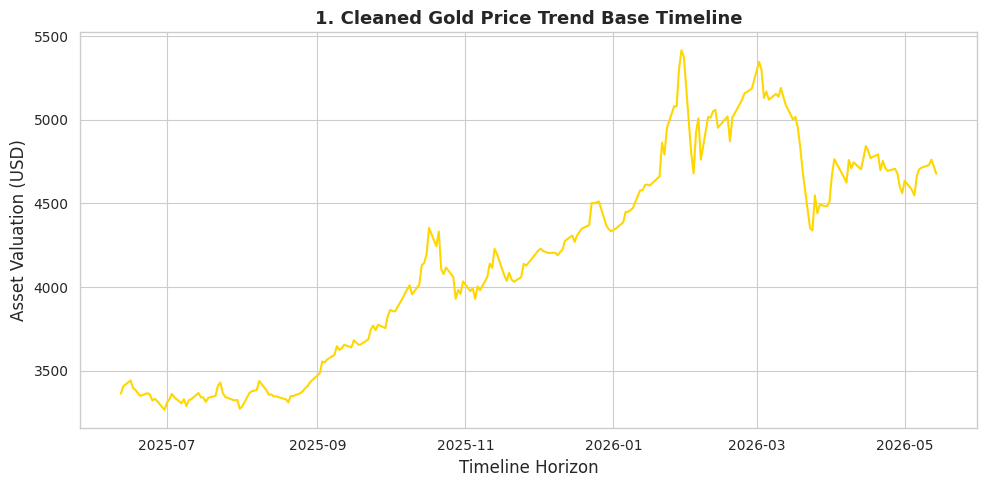

In [17]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['price'], color='gold', linewidth=1.5)
plt.title("1. Cleaned Gold Price Trend Base Timeline", fontweight='bold')
plt.xlabel("Timeline Horizon")
plt.ylabel("Asset Valuation (USD)")
plt.tight_layout()
plt.show()

# Graph 2

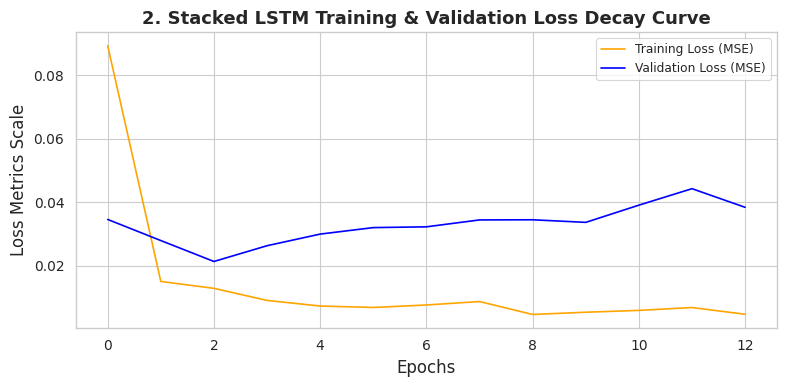

In [18]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='orange')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='blue')
plt.title("2. Stacked LSTM Training & Validation Loss Decay Curve", fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Loss Metrics Scale")
plt.legend()
plt.tight_layout()
plt.show()

# Graph 3

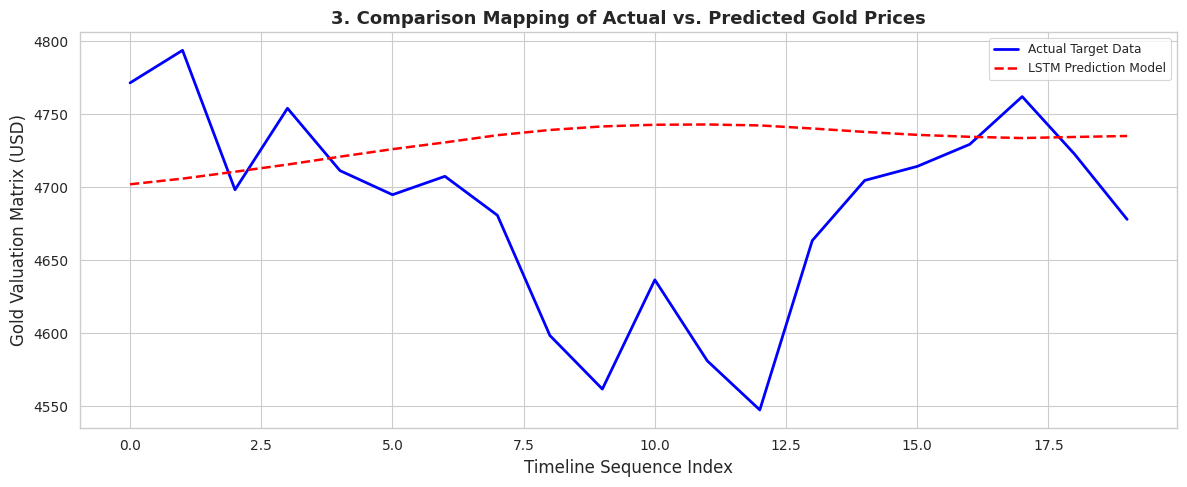

In [19]:
plt.figure(figsize=(12,5))
plt.plot(y_true, label="Actual Target Data", color='blue', linewidth=2)
plt.plot(y_pred, label="LSTM Prediction Model", color='red', linestyle='--', linewidth=1.8)
plt.title("3. Comparison Mapping of Actual vs. Predicted Gold Prices", fontweight='bold')
plt.xlabel("Timeline Sequence Index")
plt.ylabel("Gold Valuation Matrix (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# Graph 4

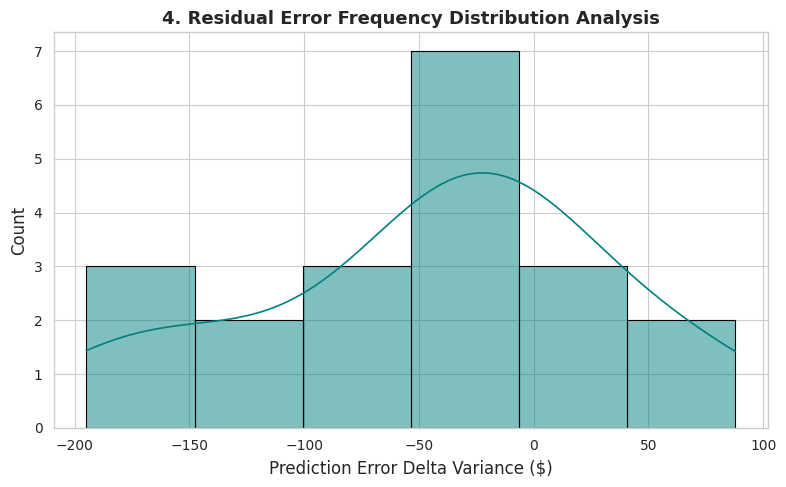

In [20]:
residuals = y_true - y_pred
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True, color='teal', edgecolor='black')
plt.title("4. Residual Error Frequency Distribution Analysis", fontweight='bold')
plt.xlabel("Prediction Error Delta Variance ($)")
plt.tight_layout()
plt.show()

# Graph 5

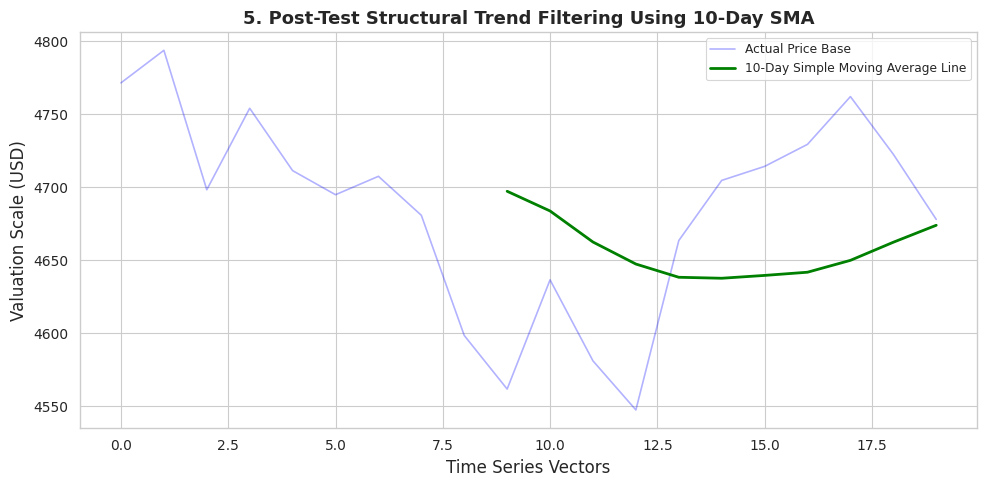

In [21]:
df_m = pd.DataFrame(y_true, columns=['Actual'])
df_m['SMA_10'] = df_m['Actual'].rolling(10).mean()
plt.figure(figsize=(10,5))
plt.plot(df_m['Actual'], label='Actual Price Base', alpha=0.3, color='blue')
plt.plot(df_m['SMA_10'], label='10-Day Simple Moving Average Line', color='green', linewidth=2)
plt.title("5. Post-Test Structural Trend Filtering Using 10-Day SMA", fontweight='bold')
plt.xlabel("Time Series Vectors")
plt.ylabel("Valuation Scale (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# Graph 6

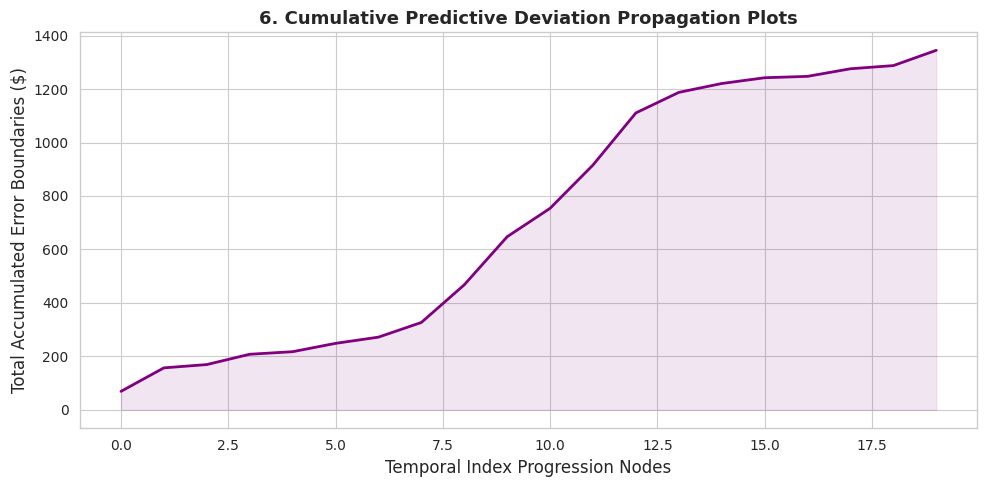

In [22]:
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(np.abs(residuals)), color='purple', linewidth=2)
plt.fill_between(range(len(residuals)), np.cumsum(np.abs(residuals)), color='purple', alpha=0.1)
plt.title("6. Cumulative Predictive Deviation Propagation Plots", fontweight='bold')
plt.xlabel("Temporal Index Progression Nodes")
plt.ylabel("Total Accumulated Error Boundaries ($)")
plt.tight_layout()
plt.show()

# Graph 7

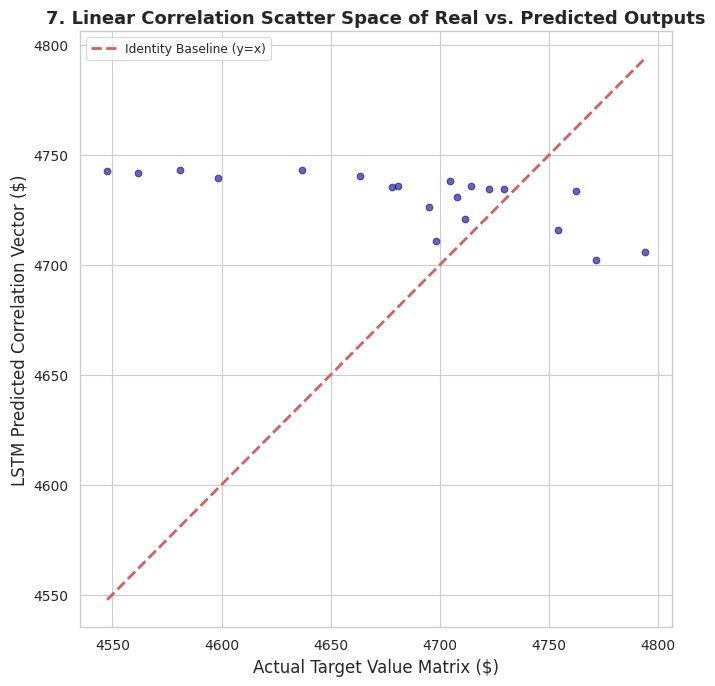

In [23]:
plt.figure(figsize=(7,7))
plt.scatter(y_true, y_pred, alpha=0.6, color='darkblue')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Identity Baseline (y=x)')
plt.title("7. Linear Correlation Scatter Space of Real vs. Predicted Outputs", fontweight='bold')
plt.xlabel("Actual Target Value Matrix ($)")
plt.ylabel("LSTM Predicted Correlation Vector ($)")
plt.legend()
plt.tight_layout()
plt.show()

# Graph 8

/tmp/ipykernel_1098/3860725629.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='price', data=df_month, order=month_order, palette='Spectral')


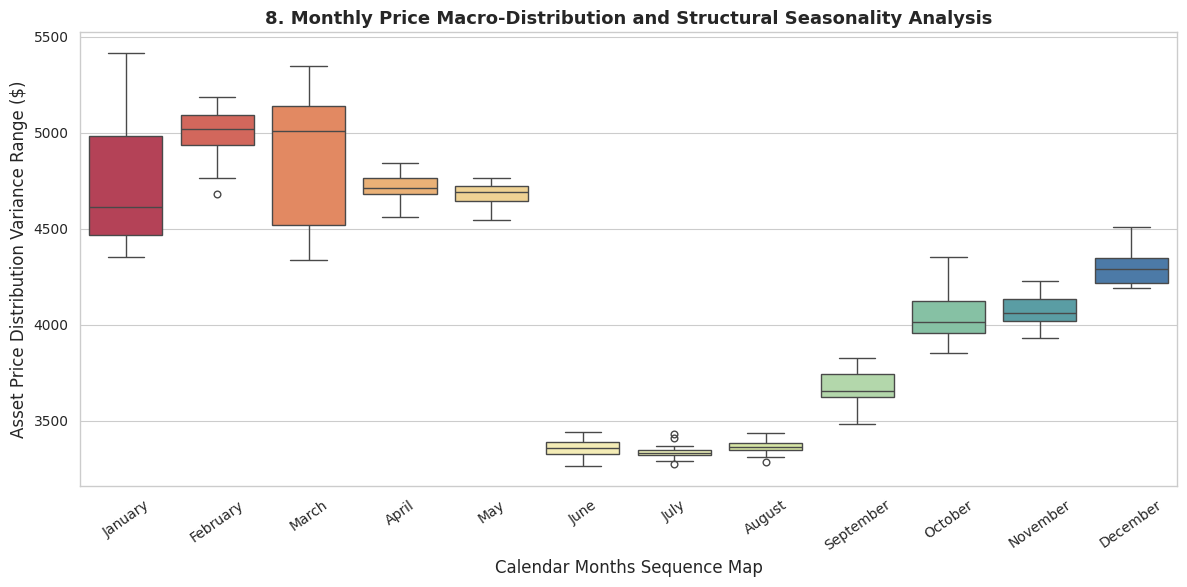

In [24]:
df_month = df.copy()
df_month['Month'] = df_month.index.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
plt.figure(figsize=(12,6))
sns.boxplot(x='Month', y='price', data=df_month, order=month_order, palette='Spectral')
plt.title("8. Monthly Price Macro-Distribution and Structural Seasonality Analysis", fontweight='bold')
plt.xlabel("Calendar Months Sequence Map")
plt.ylabel("Asset Price Distribution Variance Range ($)")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

# Graph 9

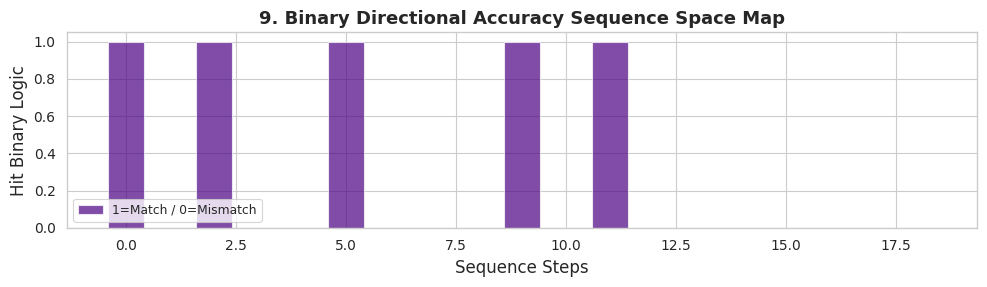

In [25]:
plt.figure(figsize=(10,3))
dir_correctness = (actual_dir == pred_dir).astype(int)
plt.bar(range(len(dir_correctness)), dir_correctness, color='indigo', alpha=0.7, label='1=Match / 0=Mismatch')
plt.title("9. Binary Directional Accuracy Sequence Space Map", fontweight='bold')
plt.xlabel("Sequence Steps")
plt.ylabel("Hit Binary Logic")
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Graph 10

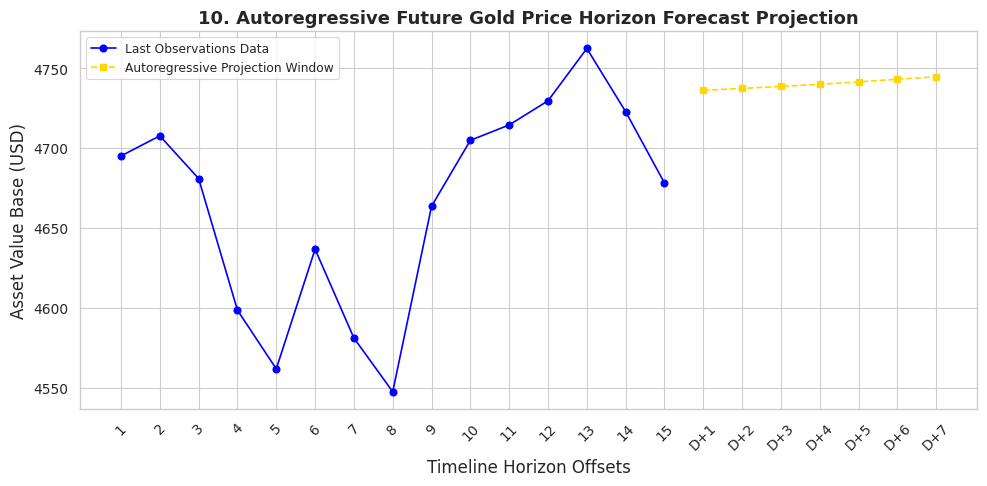

In [26]:
plt.figure(figsize=(10,5))
last_15 = y_true[-15:]
total_len = np.arange(1, len(last_15) + forecast_days + 1)
plt.plot(total_len[:len(last_15)], last_15, marker='o', color='blue', label='Last Observations Data')
plt.plot(total_len[len(last_15):], future_prices, marker='s', linestyle='--', color='gold', label='Autoregressive Projection Window')
plt.title("10. Autoregressive Future Gold Price Horizon Forecast Projection", fontweight='bold')
plt.xticks(total_len, [str(i) for i in range(1, len(last_15)+1)] + [f'D+{i}' for i in range(1, forecast_days+1)], rotation=45)
plt.xlabel("Timeline Horizon Offsets")
plt.ylabel("Asset Value Base (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# 9. EXPORT TRAINED WEIGHTS

In [27]:
model.save("gold_model.keras")
print("\n✔ Model successfully exported and serialized as 'gold_model.keras'")


✔ Model successfully exported and serialized as 'gold_model.keras'
